# 02 — Error Analysis and Evaluation

This notebook analyses the saved outputs from the refactored baseline run.

Focus:
- overall held-out metrics
- training/validation dynamics
- per-horizon error growth
- supplementary weighted MAE and SSIM
- interpretation of what the metrics imply about model behaviour

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

OUTPUTS_DIR = Path("../outputs")
METRICS_DIR = OUTPUTS_DIR / "metrics"
REPORT_FIGURES_DIR = Path("../reports/figures")

baseline_metrics_csv = METRICS_DIR / "baseline_desktop_eval.csv"
weighted_metrics_csv = METRICS_DIR / "weighted_mae_eval_eval.csv"
horizon_csv = METRICS_DIR / "weighted_mae_eval_mae_per_horizon.csv"
history_json = METRICS_DIR / "history.json"  # adjust if you move/rename it
baseline_train_json = METRICS_DIR / "baseline_desktop.json"  # adjust if needed

for p in [baseline_metrics_csv, weighted_metrics_csv, horizon_csv]:
    print(p, "exists:", p.exists())

../outputs/metrics/baseline_desktop_eval.csv exists: True
../outputs/metrics/weighted_mae_eval_eval.csv exists: True
../outputs/metrics/weighted_mae_eval_mae_per_horizon.csv exists: True


In [7]:
baseline_metrics = pd.read_csv(baseline_metrics_csv)
weighted_metrics = pd.read_csv(weighted_metrics_csv)
horizon_df = pd.read_csv(horizon_csv)

baseline_metrics

,metric,value
0,mae,0.035699
1,mse,0.006938
2,rmse,0.078901


In [8]:
weighted_metrics

,metric,value
0,mae,0.035699
1,mse,0.006938
2,rmse,0.078901
3,ssim,0.734417
4,weighted_mae,0.050662


## Overall held-out performance

The refactored baseline establishes a clean storm-wise held-out benchmark before any loss-function changes.

The main quantities of interest are:

- MAE: original benchmark-aligned metric
- RMSE: error magnitude with stronger penalty for larger deviations
- weighted MAE: intensity-aware error emphasis
- SSIM: structural fidelity

In [9]:
metric_table = (
    weighted_metrics
    .pivot_table(index=None, columns="metric", values="value")
    .round(6)
)

metric_table

metric,mae,mse,rmse,ssim,weighted_mae
value,0.035699,0.006938,0.078901,0.734417,0.050662


## Training dynamics

The baseline was selected using validation performance, not test performance.

This notebook treats the saved best validation checkpoint as the canonical model and uses the test split only for final reporting.

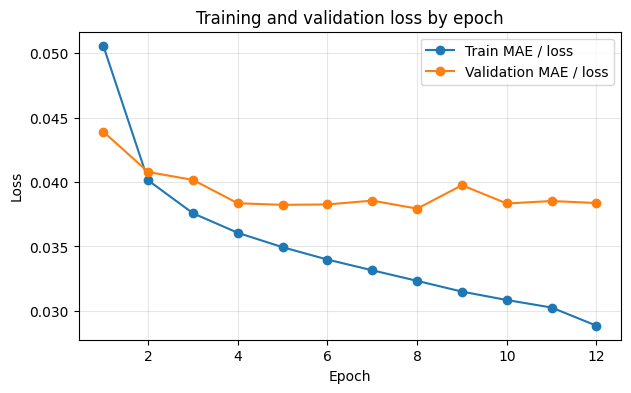

In [10]:
with open(history_json, "r") as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train MAE / loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation MAE / loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss by epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

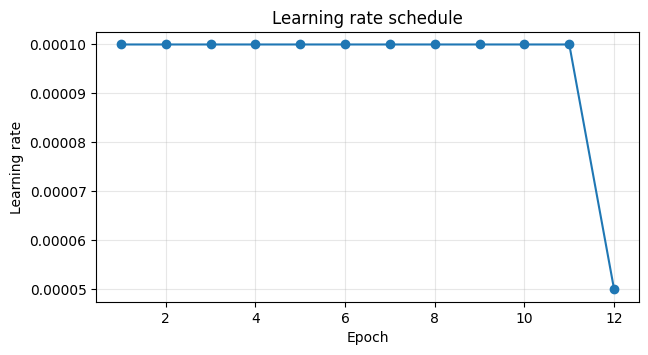

In [11]:
plt.figure(figsize=(7, 3.5))
plt.plot(epochs, history["lr"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation of training behaviour

The training curve shows:

- strong early improvement in both train and validation loss
- a best validation checkpoint around the middle of training
- later validation plateauing while training loss continues to fall
- a learning-rate reduction late in training
- early stopping after the model stops improving on validation

This is the expected pattern for a reasonable baseline rather than a broken optimisation run.

In [12]:
best_epoch = int(pd.Series(history["val_loss"]).idxmin()) + 1
best_val = float(min(history["val_loss"]))

print("Best epoch:", best_epoch)
print("Best validation loss / MAE:", round(best_val, 6))
print("Final learning rate:", history["lr"][-1])

Best epoch: 8
Best validation loss / MAE: 0.037932
Final learning rate: 5e-05


## Horizon-wise error growth

A single aggregate MAE hides where the forecast becomes difficult.

For this task, horizon-wise error matters because:
- short-horizon localisation is easier
- long-horizon motion and morphology are harder
- smoothing and drift usually become more visible later in the sequence

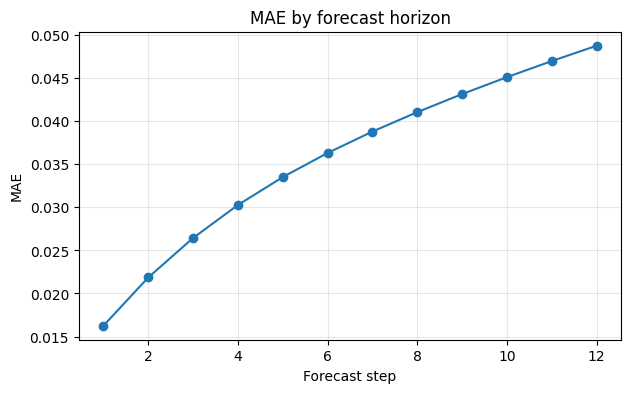

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(horizon_df["forecast_step"], horizon_df["mae"], marker="o")
plt.xlabel("Forecast step")
plt.ylabel("MAE")
plt.title("MAE by forecast horizon")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
horizon_df.round(6)

,forecast_step,mae
0,1,0.016262
1,2,0.021861
2,3,0.026439
3,4,0.030268
4,5,0.033503
5,6,0.036299
6,7,0.038785
7,8,0.041039
8,9,0.043132
9,10,0.045095


## Interpretation of horizon-wise performance

The horizon curve should increase steadily with lead time.

That behaviour is expected:
- uncertainty compounds across the forecast horizon
- storm position, structure, and intensity become less predictable further ahead
- pixelwise losses tend to encourage conservative, smoother forecasts at later steps

This pattern is one of the main reasons to include qualitative analysis alongside scalar metrics.

## Why weighted MAE and SSIM matter here

The baseline was trained with MAE because that matched the original coursework metric.

That remains the right reference point.

However, MAE alone does not fully answer two useful questions:

1. Are errors on stronger storm regions being under-emphasised?
2. Are forecasts structurally plausible, or just smooth enough to keep pixelwise error modest?

Weighted MAE addresses the first question.
SSIM addresses the second.

In [15]:
summary = metric_table.T.rename(columns={0: "value"})
summary

,value
metric,
mae,0.035699
mse,0.006938
rmse,0.078901
ssim,0.734417
weighted_mae,0.050662


## Metric interpretation

The gap between standard MAE and weighted MAE suggests that the baseline is materially worse once stronger storm regions are given more importance.

SSIM remains reasonably solid, but the qualitative panels show that later-horizon predictions still blur and simplify structure.

Taken together, this supports the next-stage experimental plan:

- keep the current MAE-trained baseline as the reference point
- test weighted MAE and SSIM first as **evaluation metrics**
- only then decide whether a modified training objective is worth the added complexity

## Key takeaways

- the refactored repo now produces a clean held-out baseline
- the selected checkpoint comes from validation, not test peeking
- later-horizon error growth is smooth and interpretable
- supplementary metrics confirm that high-intensity and structural fidelity are the main weaknesses to target next